In [1]:
# FIRST physical cell: standard-library contract before numerical imports/output.
from pathlib import Path
import hashlib, json
BASE = Path.cwd()
EXPECTED = {'data/observations.csv': '35883db0ff9fc950e5db316a02064addf6bbe28bddef70a23ee001c74c119681', 'data/separable.csv': 'c64e413f86880a4ca5b07333f9e0260987e586d728c2b0f90fbb01bf20a63ab5', 'data/model_spec.json': 'ffca7b1787ed6163b9f142403bc2ef17b70dbf6fb6eafb00a5188018261c6d52', 'experiment.py': 'aea567ab318a2cf5397d52e16eab5c8d9e00bdb89851502253a306070bf823ab', 'plots.py': '2bbd904224a1e257c9a32075a80ebedf4210318096ad5cbc963cd0d9afc08e78', 'audit.py': '056521cd74094770b57c733113057f2f1ddb9687c9b5b1bed02f5b71b207f862', 'requirements.txt': '9e91f804d22f2028e35dced18587b0fbbb734cd3f7f2df7b57b1360b2213b833', 'environment.yml': '906696751275ab026c9651179625c86ae803ca844389028c9432dc1a20a698f7', 'data_integrity.json': '7302317874abad532e93aa944e52941cec9359511d6081700b9b97c8d8249e3c'}
for relative, expected in EXPECTED.items():
    if hashlib.sha256((BASE / relative).read_bytes()).hexdigest() != expected:
        raise ValueError('teaching fixture changed: ' + relative)
print('Nine exact teaching contracts verified before numerical work.')

Nine exact teaching contracts verified before numerical work.


# 第042讲 二分类与逻辑回归
主例有限MLE与另一个完全分离例必须区分。所有数据合成。依次运行，保留完整行级计算、真实图像与警告。

Rows: [('B1', -2.0, 0.0), ('B2', -1.0, 1.0), ('B3', 1.0, 0.0), ('B4', 2.0, 1.0)]
Versions: {'numpy': '2.3.5', 'scipy': '1.17.0', 'sklearn': '1.8.0'}


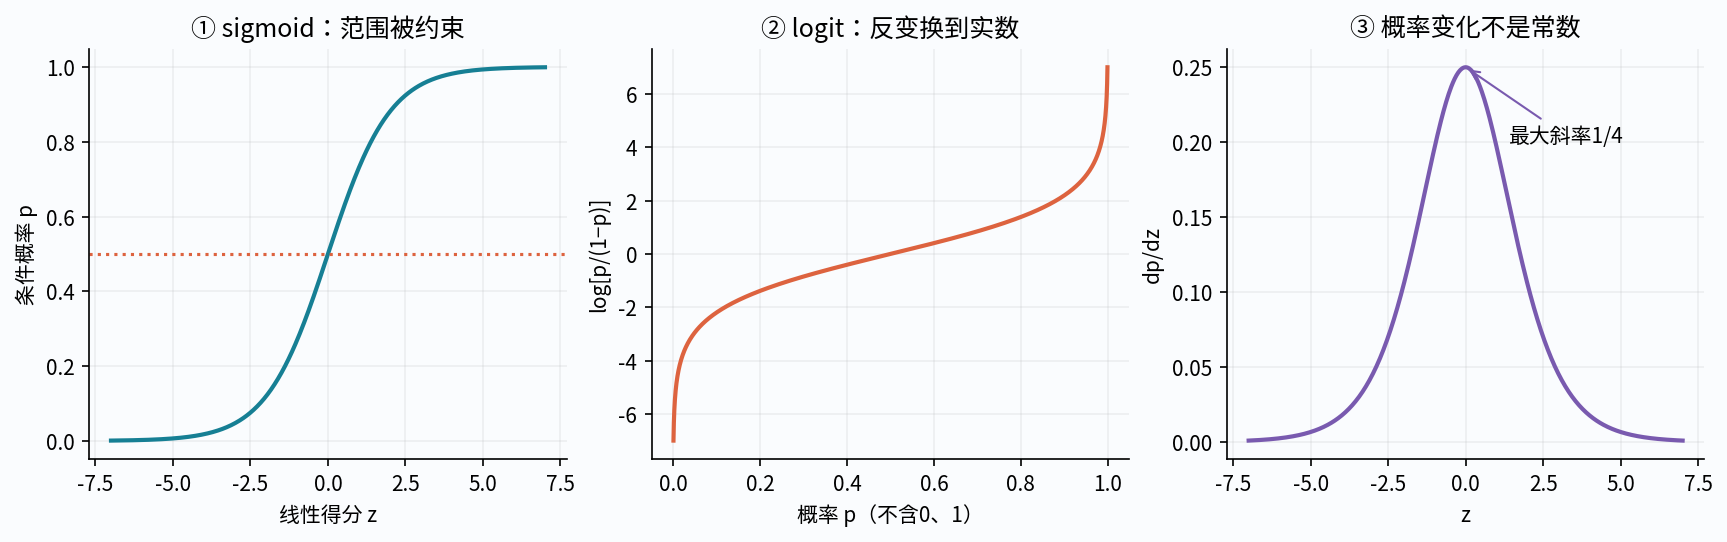

In [2]:
import numpy as np
import experiment as e
import plots
import matplotlib.pyplot as plt
from IPython.display import display, Image
import io

def show(number, report):
    fig = plots.make_figure(number, report)
    buffer = io.BytesIO()
    fig.savefig(buffer, format='png', dpi=150, bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

x, y, ids, sx, sy, sids, cfg = e.load_inputs()
# Actual scratch optimizers, sklearn fits and finite differences execute here.
report = e.main_report(x, y, ids, sx, sy, sids, cfg)
print('Rows:', list(zip(ids, x.tolist(), y.tolist())))
print('Versions:', report['versions'])
show(1, report)

## 概率模型与每一段导数
数学上0<p<1；极端概率不通过无穷乘0计算导数。

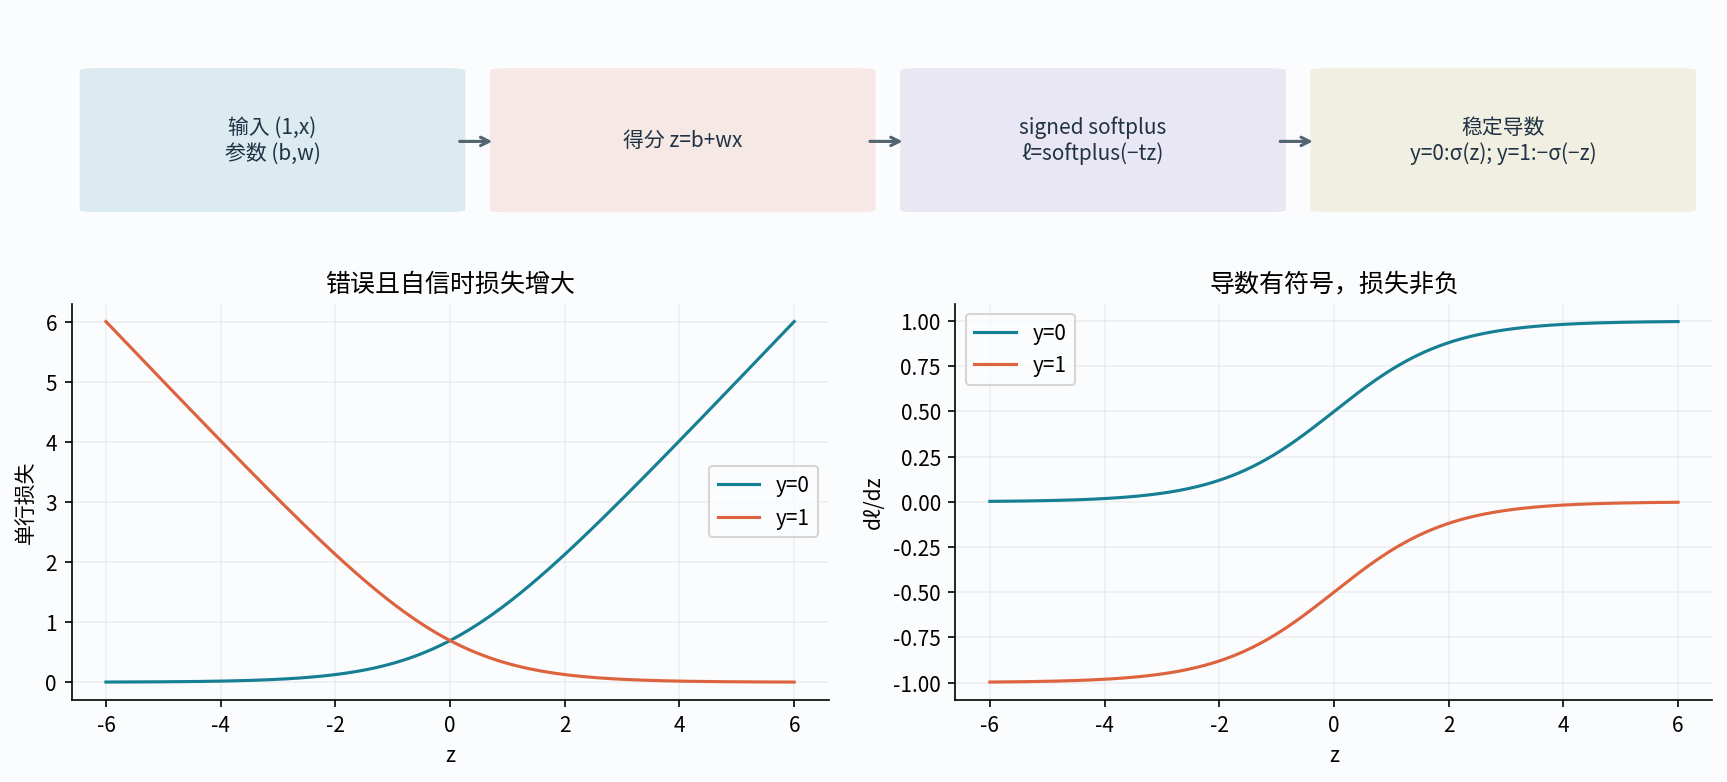

State 0 theta [0.0, 0.0] F 0.6931471805599453 g [0.0, -0.25]
State 1 theta [0.0, 0.125] F 0.6667692275980063 g [0.0, -0.17221881242732373]
State 2 theta [0.0, 0.21110940621366187] F 0.6542101267359844 g [0.0, -0.11969482505055373]


In [3]:
show(2, report)
theta = np.array(cfg['initial_parameters'])
independent_hand = []
for k in range(3):
    state = e.row_ledger(x, y, theta)
    independent_hand.append(state)
    print('State', k, 'theta', state['theta'], 'F', state['data_loss'], 'g', state['gradient'])
    if k < 2:
        theta = theta - cfg['learning_rate'] * np.array(state['gradient'])
if e.canonical_bytes(independent_hand) != e.canonical_bytes(report['hand_states']):
    raise RuntimeError('hand computation did not match optimizer states')


FULL ROW CHAIN state 0
{"complement_probability": 0.5, "gradient_contribution": [0.125, -0.25], "hessian_contribution": [[0.0625, -0.125], [-0.125, 0.25]], "jacobian": [1.0, -2.0], "local_dloss_dp": 2.0, "local_dp_dz": 0.25, "logit": 0.0, "loss": 0.6931471805599453, "mean_loss_contribution": 0.17328679513998632, "probability": 0.5, "row": 1, "stable_dloss_dz": 0.5, "tail_underflow": false, "x": -2.0, "y": 0}
{"complement_probability": 0.5, "gradient_contribution": [-0.125, 0.125], "hessian_contribution": [[0.0625, -0.0625], [-0.0625, 0.0625]], "jacobian": [1.0, -1.0], "local_dloss_dp": -2.0, "local_dp_dz": 0.25, "logit": 0.0, "loss": 0.6931471805599453, "mean_loss_contribution": 0.17328679513998632, "probability": 0.5, "row": 2, "stable_dloss_dz": -0.5, "tail_underflow": false, "x": -1.0, "y": 1}
{"complement_probability": 0.5, "gradient_contribution": [0.125, 0.125], "hessian_contribution": [[0.0625, 0.0625], [0.0625, 0.0625]], "jacobian": [1.0, 1.0], "local_dloss_dp": 2.0, "local_dp

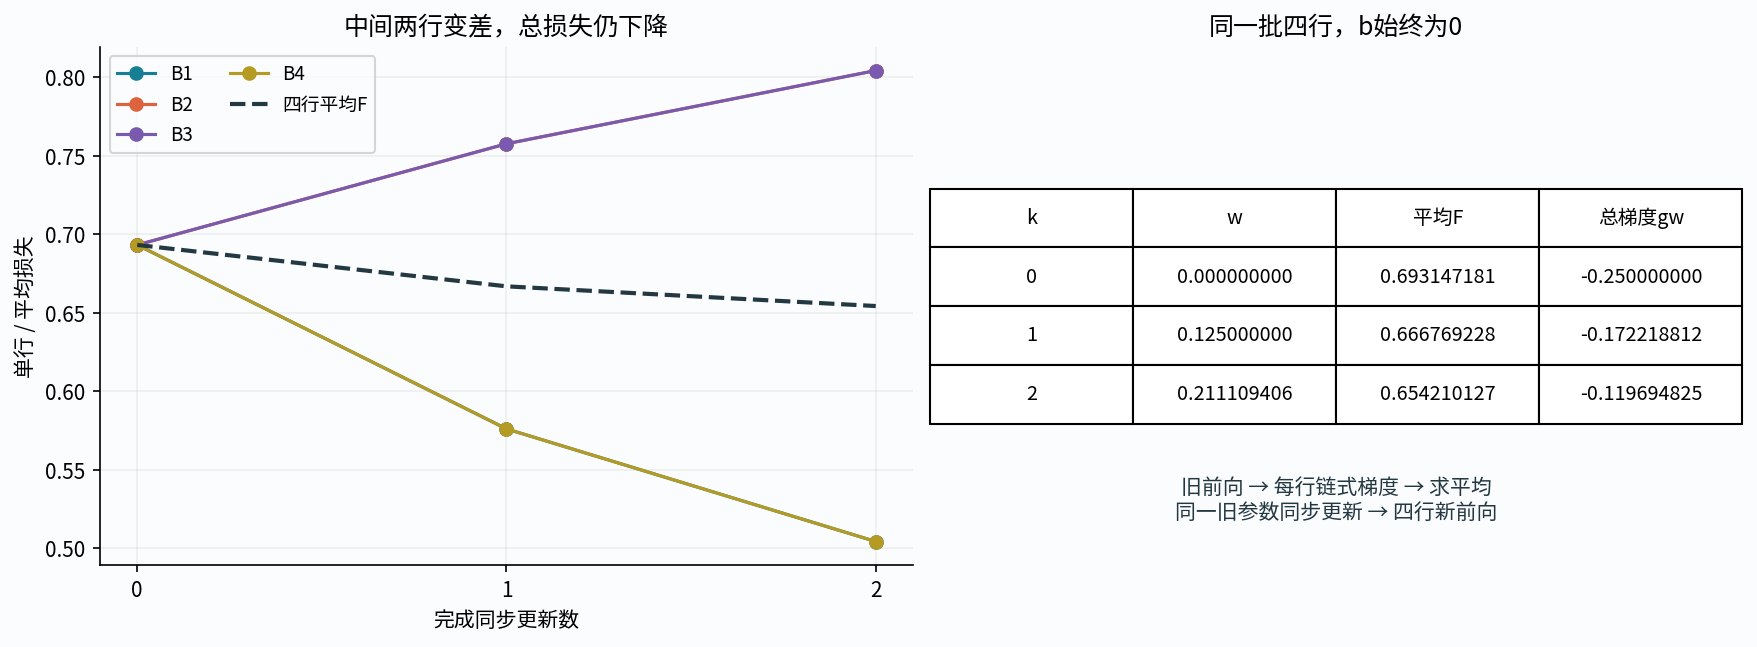

In [4]:
for k, state in enumerate(independent_hand):
    print('\nFULL ROW CHAIN state', k)
    for row in state['rows']:
        print(json.dumps(row, ensure_ascii=False, sort_keys=True))
    print('Full gradient:', state['gradient'], 'Hessian:', state['hessian'])
show(3, report)

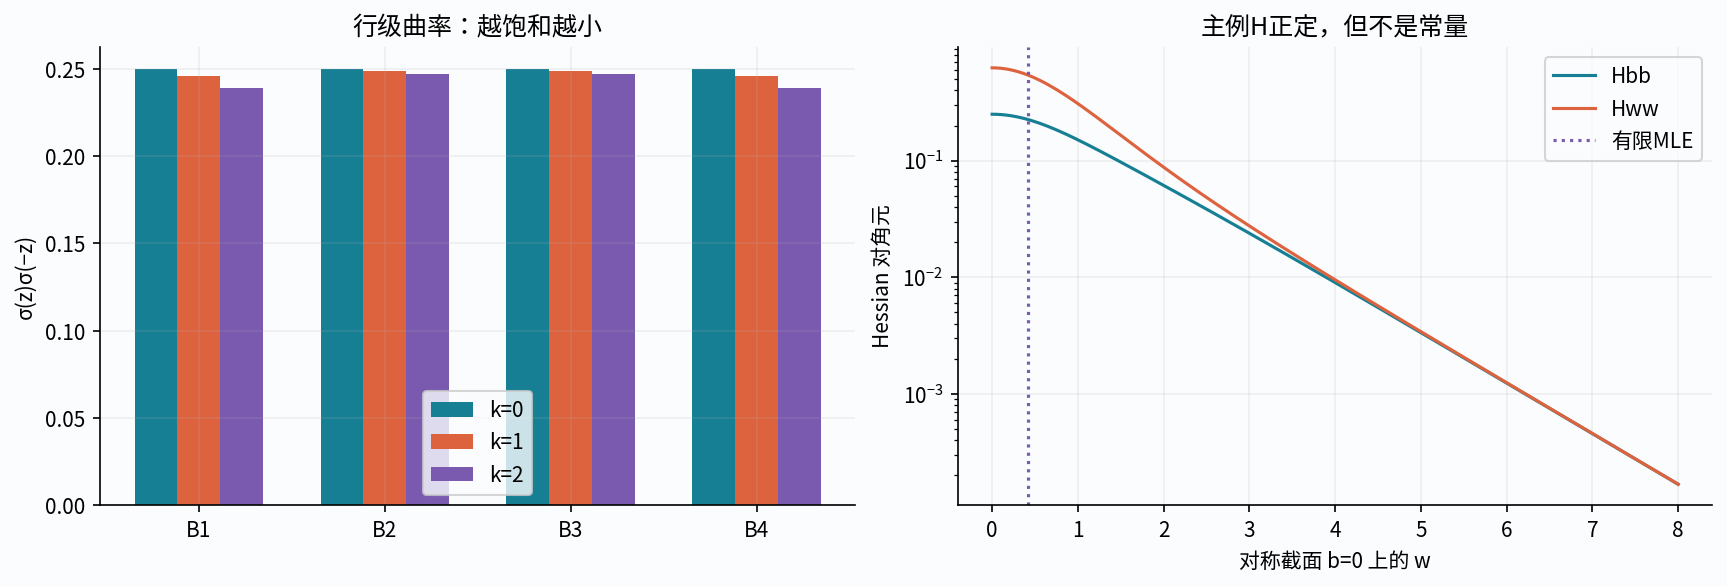

Global smoothness bound: 0.625 eta: 0.5
Newton first direction: [-0.   0.4]


In [5]:
show(4, report)
A = np.column_stack((np.ones(len(x)), x))
L_bound = np.linalg.eigvalsh(A.T @ A / (4 * len(x)))[-1]
print('Global smoothness bound:', L_bound, 'eta:', cfg['learning_rate'])
print('Newton first direction:', -np.linalg.solve(independent_hand[0]['hessian'], independent_hand[0]['gradient']))

## 数值停止和存在性分别证明

gd status gradient_tolerance updates 68 final [0.0, 0.4196176248168132]
gradient norm 9.428907654651653e-11 cost {'state_attempts': 69, 'state_successes': 69, 'sample_forward_attempts': 276, 'sample_gradient_attempts': 276, 'sample_hessian_attempts': 276, 'solve_attempts': 0, 'cholesky_attempts': 0}
newton status gradient_tolerance updates 4 final [1.1989552950868877e-18, 0.41961762499109795]
gradient norm 5.551115123125783e-17 cost {'state_attempts': 5, 'state_successes': 5, 'sample_forward_attempts': 20, 'sample_gradient_attempts': 20, 'sample_hessian_attempts': 20, 'solve_attempts': 4, 'cholesky_attempts': 4}
regularized_newton status gradient_tolerance updates 3 final [2.8055848876374155e-19, 0.2905219321147506]
gradient norm 2.021036116239827e-12 cost {'state_attempts': 4, 'state_successes': 4, 'sample_forward_attempts': 16, 'sample_gradient_attempts': 16, 'sample_hessian_attempts': 16, 'solve_attempts': 3, 'cholesky_attempts': 3}


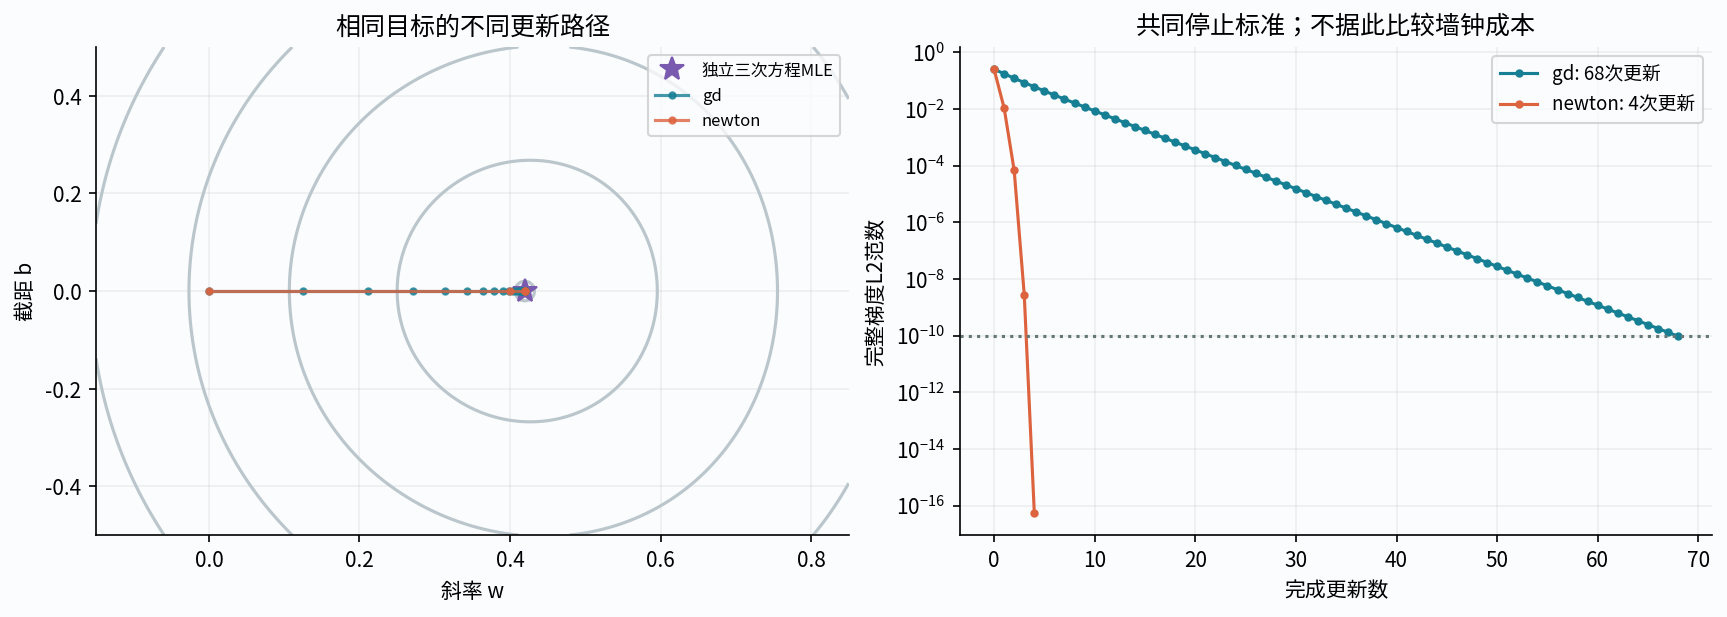

In [6]:
for key in ['gd', 'newton', 'regularized_newton']:
    fitted = report[key]
    print(key, 'status', fitted['status'], 'updates', fitted['updates'], 'final', fitted['final']['theta'])
    print('gradient norm', fitted['final']['gradient_norm'], 'cost', fitted['cost'])
show(5, report)

In [7]:
certificate = e.cubic_certificate()
print('Independent 110-digit cubic certificate:', certificate)
print('Full stationary gradient:', e.row_ledger(x, y, [0, float(certificate['w'])])['gradient'])
print('Final main probabilities:', [v['probability'] for v in report['newton']['final']['rows']])
print('Hard threshold .5 accuracy:', report['decisions'][1]['accuracy'])

Independent 110-digit cubic certificate: {'precision': 110, 't': '1.5213797068045675696040808322544385144283898284279039090904980154281564034305882160491637926967338770567943892', 'w': '0.41961762499109789953431064679925369045116365171158147620925542817344218945606553028105286705931848782679149765', 'cubic_residual': '6E-109', 'interval_width': '1E-109', 'scope': 'only the declared symmetric four-row main example; strict convexity plus full two-dimensional stationary point proves unique finite MLE'}
Full stationary gradient: [0.0, 0.0]
Final main probabilities: [0.3016958736319539, 0.3966082527360922, 0.6033917472639079, 0.6983041263680461]
Hard threshold .5 accuracy: 0.5


Separate labels: [0.0, 0.0, 1.0, 1.0]
{'scale': 0.0, 'loss': 0.6931471805599453, 'gradient_norm': 0.75, 'theta_norm': 0.0, 'minimum_margin': 0.0, 'hessian_eigenvalues': [0.25, 0.625]}
{'scale': 1.0, 'loss': 0.2200948492805977, 'gradient_norm': 0.25367363270711507, 'theta_norm': 1.0, 'minimum_margin': 1.0, 'hessian_eigenvalues': [0.15080275932249418, 0.3082931374277539]}
{'scale': 2.0, 'loss': 0.07253896948039111, 'gradient_norm': 0.07758767097315034, 'theta_norm': 2.0, 'minimum_margin': 2.0, 'hessian_eigenvalues': [0.0613281458083988, 0.08782220512833547]}
{'scale': 4.0, 'loss': 0.009242667145352754, 'gradient_norm': 0.009328455111512255, 'theta_norm': 4.0, 'minimum_margin': 4.0, 'hessian_eigenvalues': [0.008998971942023794, 0.009501828448158505]}
{'scale': 8.0, 'loss': 0.000167759454032078, 'gradient_norm': 0.0001677876003952942, 'theta_norm': 8.0, 'minimum_margin': 8.0, 'hessian_eigenvalues': [0.00016767510295293263, 0.000167843905677019]}
{'scale': 16.0, 'loss': 5.626759052567119e-0

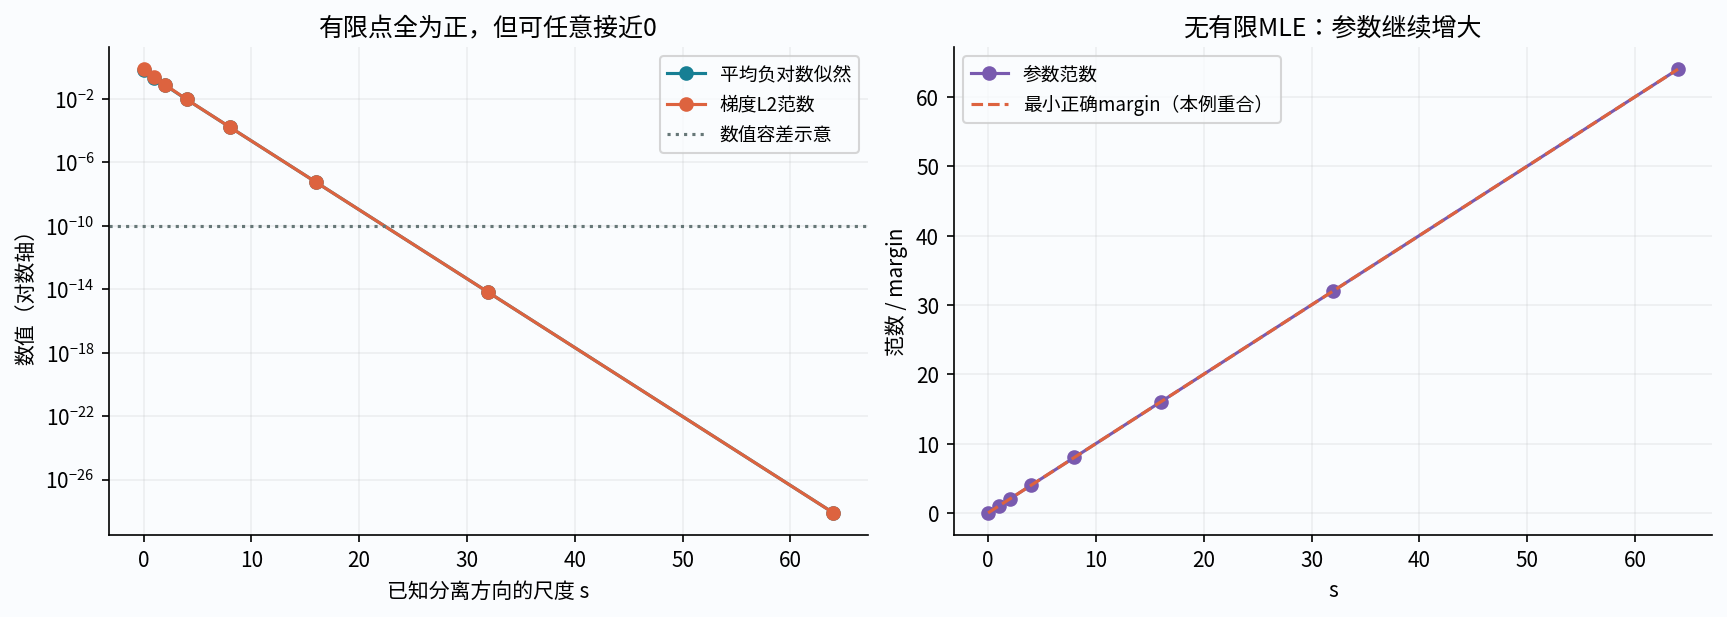

Known ray certificate applies: True
A small gradient along this ray does NOT certify a finite MLE.


In [8]:
print('Separate labels:', sy.tolist())
for row in report['separation_ray']:
    print(row)
show(6, report)
print('Known ray certificate applies:', report['separation_certificate_applies'])
print('A small gradient along this ray does NOT certify a finite MLE.')

In [9]:
try:
    e.fit(x, np.ones_like(y), lam=.25)
except ValueError as failure:
    print('Single-class fit correctly rejected:', failure)
else:
    raise RuntimeError('single-class fit was not rejected')
rank_deficient = e.fit([1, 1], [0, 1], initial=[0, 0])
print('Constant feature with two classes:', rank_deficient['status'], rank_deficient['updates'])
print('Slope L2 leaves intercept unpenalized.')

Single-class fit correctly rejected: fit requires both label classes
Constant feature with two classes: gradient_tolerance 0
Slope L2 leaves intercept unpenalized.


## 目标对齐之后才比较成熟库

In [10]:
for fitted in report['library']:
    print('lambda', fitted['lambda'], 'C', fitted['C'], 'C is infinity', fitted['C_unregularized_infinity'])
    print('classes', fitted['classes'], 'theta', fitted['theta'], 'n_iter', fitted['n_iter'])
    print('recomputed gradient norm', fitted['gradient_norm'], 'warnings', fitted['warnings'])
    print('zero score control (not fitted coefficients):', fitted['controlled_zero_score_probe'])
dup = report['duplicated_regularized_library']
print('Duplicated rows C:', dup['C'], 'theta:', dup['theta'])

lambda 0.0 C None C is infinity True
classes [0.0, 1.0] theta [-3.8548207601411e-17, 0.4196176249908703] n_iter [4]
recomputed gradient norm 1.2312373343092986e-13 warnings [{'category': 'UserWarning', 'message': 'Setting penalty=None will ignore the C and l1_ratio parameters'}]
zero score control (not fitted coefficients): {'library_predict': 0, 'own_probability_ge_half': 1, 'not_fitted_score': True}
lambda 0.25 C 1.0 C is infinity False
classes [0.0, 1.0] theta [-6.793276695390683e-17, 0.2905219321164236] n_iter [4]
recomputed gradient norm 6.283168436118438e-13 warnings []
zero score control (not fitted coefficients): {'library_predict': 0, 'own_probability_ge_half': 1, 'not_fitted_score': True}
Duplicated rows C: 0.5 theta: [-3.4984550923956766e-17, 0.2905219321164236]


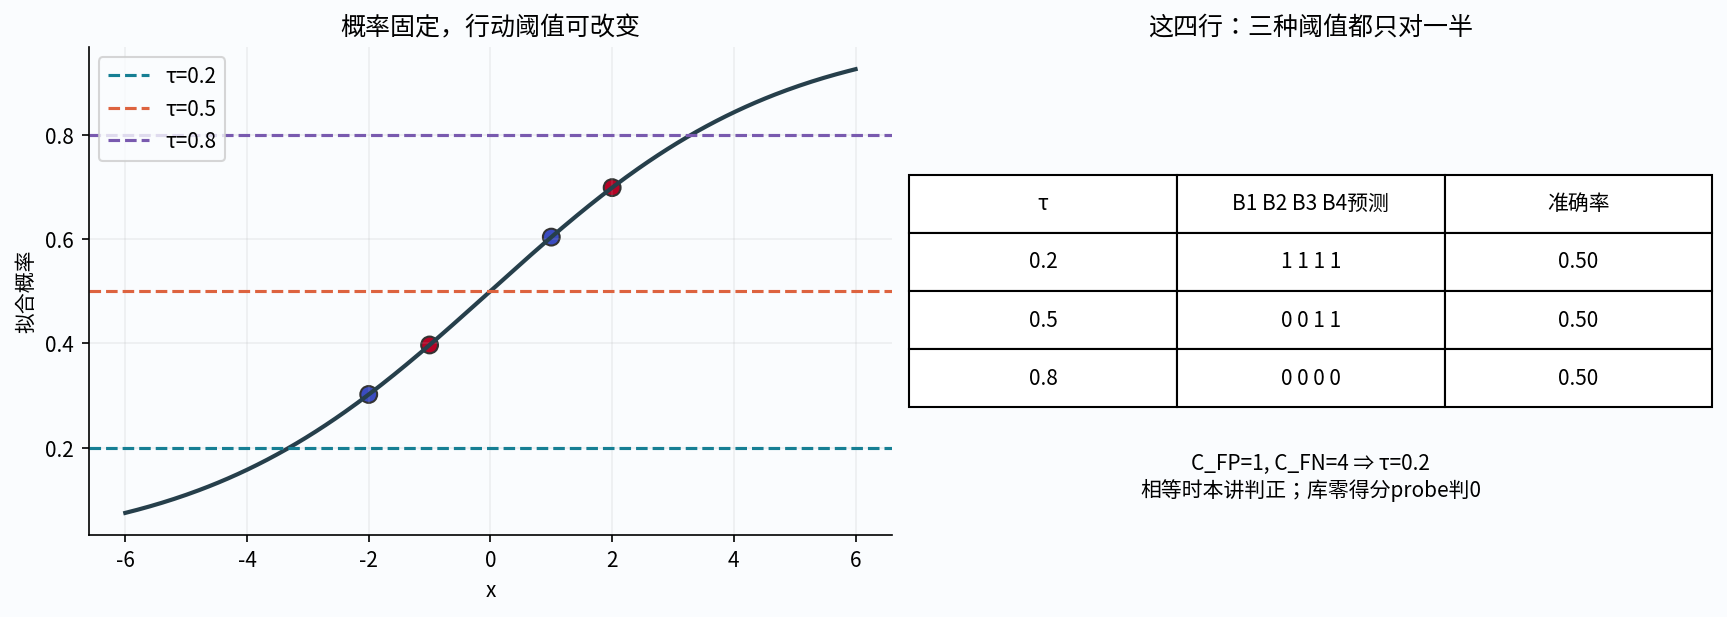

{'threshold': 0.2, 'predictions': [1, 1, 1, 1], 'accuracy': 0.5}
{'threshold': 0.5, 'predictions': [0, 0, 1, 1], 'accuracy': 0.5}
{'threshold': 0.8, 'predictions': [0, 0, 0, 0], 'accuracy': 0.5}
Predeclared cost threshold: 0.2


In [11]:
show(7, report)
for row in report['decisions']:
    print(row)
C_FP, C_FN = 1, 4
print('Predeclared cost threshold:', C_FP / (C_FP + C_FN))

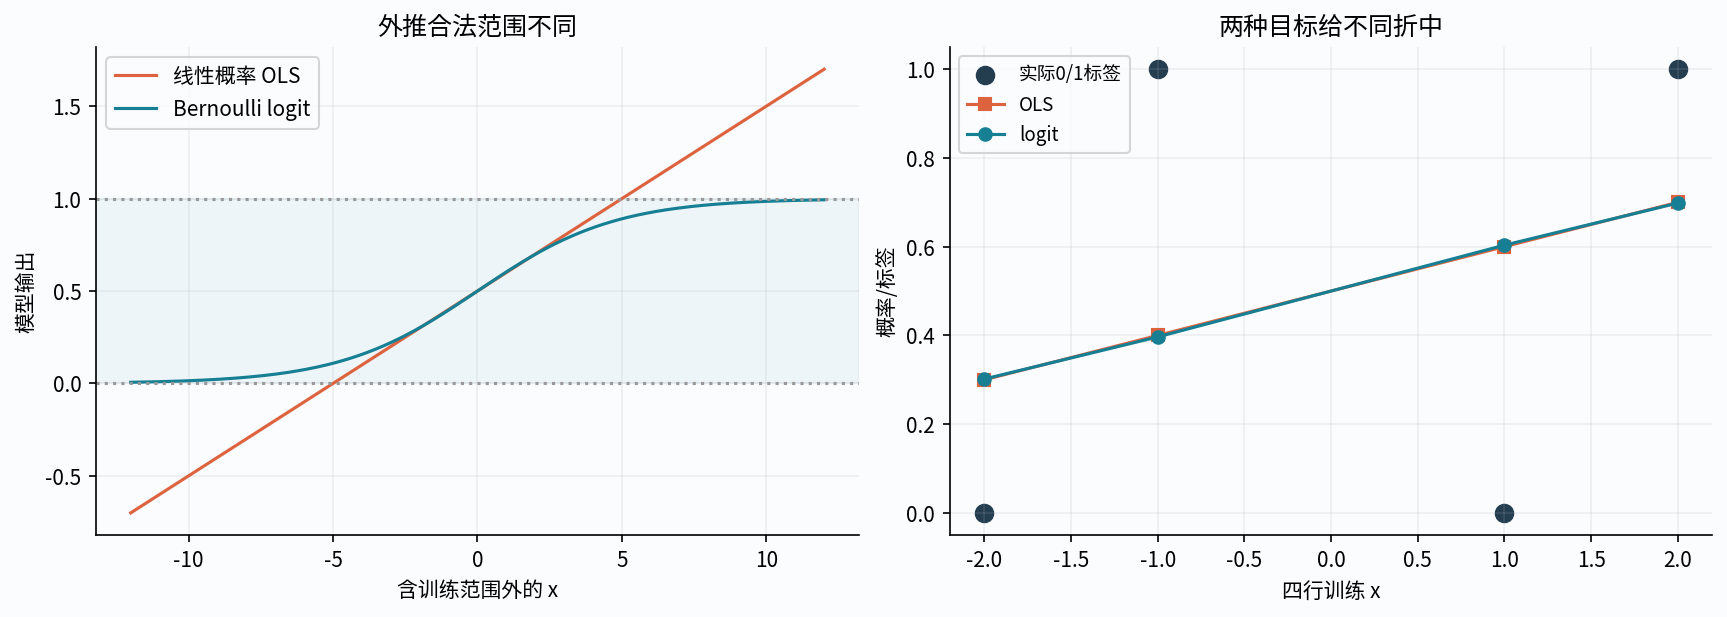

Linear probability OLS: {'theta': [0.5, 0.1], 'at_x_10': 1.5}
Clipping changes the prediction rule; it does not replace the fitting objective.


In [12]:
show(8, report)
print('Linear probability OLS:', report['linear_probability'])
print('Clipping changes the prediction rule; it does not replace the fitting objective.')

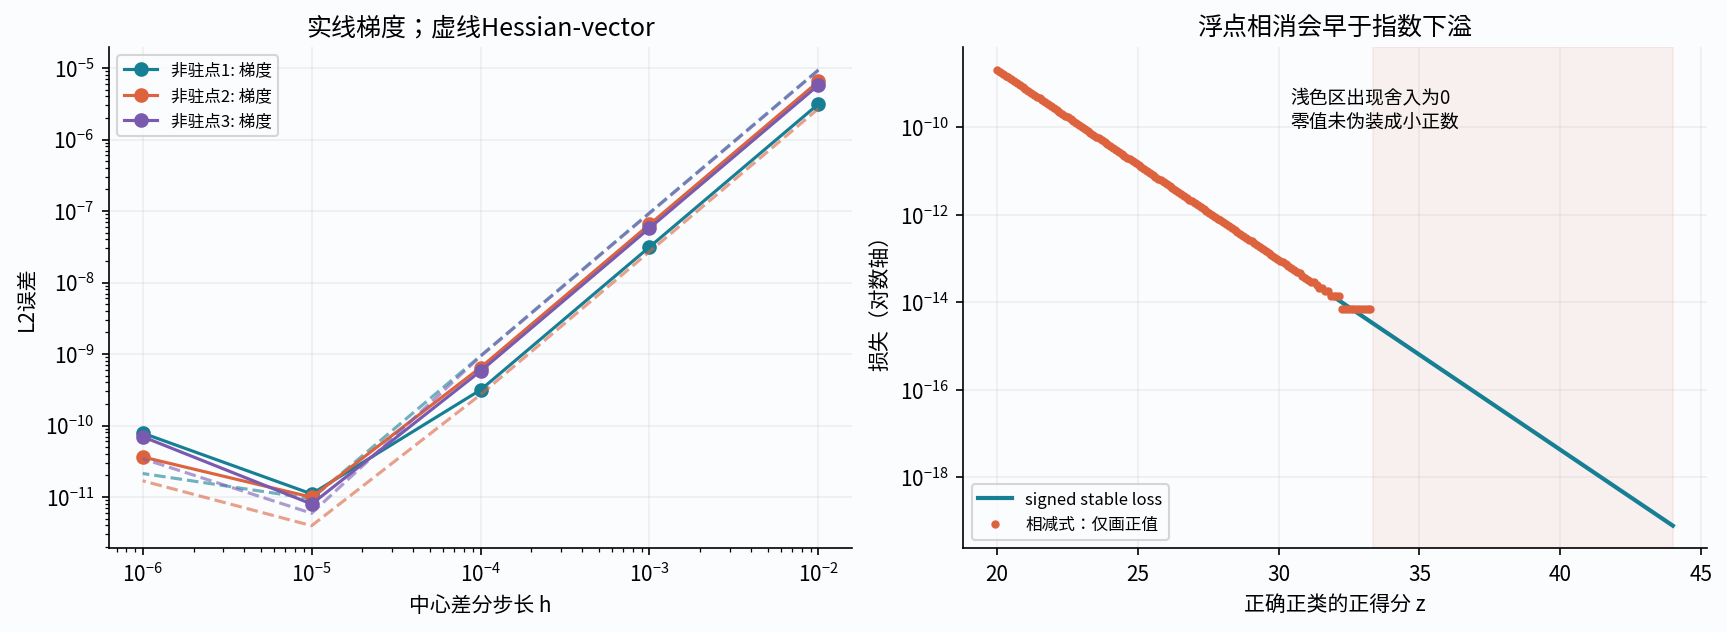

{'theta': [0.3, -0.2], 'h': 0.01, 'gradient_error': 3.137728961911862e-06, 'hvp_error': 9.44617881756236e-06}
{'theta': [0.3, -0.2], 'h': 0.001, 'gradient_error': 3.1378252052997104e-08, 'hvp_error': 9.446337205771262e-08}
{'theta': [0.3, -0.2], 'h': 0.0001, 'gradient_error': 3.146804723709296e-10, 'hvp_error': 9.44000488349118e-10}
{'theta': [0.3, -0.2], 'h': 1e-05, 'gradient_error': 1.1044157439007757e-11, 'hvp_error': 9.45836833577406e-12}
{'theta': [0.3, -0.2], 'h': 1e-06, 'gradient_error': 7.826180263054113e-11, 'hvp_error': 2.1315831774092485e-11}
{'theta': [-0.4, 0.7], 'h': 0.01, 'gradient_error': 6.481238332570558e-06, 'hvp_error': 2.7037445627421666e-06}
{'theta': [-0.4, 0.7], 'h': 0.001, 'gradient_error': 6.481352736388455e-08, 'hvp_error': 2.7040109880735297e-08}
{'theta': [-0.4, 0.7], 'h': 0.0001, 'gradient_error': 6.476125069841757e-10, 'hvp_error': 2.70436990755627e-10}
{'theta': [-0.4, 0.7], 'h': 1e-05, 'gradient_error': 9.93061477639265e-12, 'hvp_error': 3.9711373085490

In [13]:
show(9, report)
for row in report['diagnostics']['finite_difference']:
    print(row)
for row in report['diagnostics']['tails']:
    print(row)

## 真实边界路径与完整文件
按尝试和成功返回分开记账；不把0次提交写成0成本。

In [14]:
for label, kwargs in [('one update', {'max_updates': 1}),
                      ('stationary', {'initial': [0, float(certificate['w'])]}),
                      ('rejected first step', {'learning_rate': 100, 'max_updates': 1})]:
    fitted = e.fit(x, y, **kwargs)
    print(label, fitted['status'], fitted['updates'], fitted['final']['theta'], fitted['cost'])
    print('second update exists:', fitted['trace'][2]['theta'] if len(fitted['trace']) > 2 else None)

one update max_updates 1 [0.0, 0.125] {'state_attempts': 2, 'state_successes': 2, 'sample_forward_attempts': 8, 'sample_gradient_attempts': 8, 'sample_hessian_attempts': 8, 'solve_attempts': 0, 'cholesky_attempts': 0}
second update exists: None
stationary gradient_tolerance 0 [0.0, 0.4196176249910979] {'state_attempts': 1, 'state_successes': 1, 'sample_forward_attempts': 4, 'sample_gradient_attempts': 4, 'sample_hessian_attempts': 4, 'solve_attempts': 0, 'cholesky_attempts': 0}
second update exists: None
rejected first step step_rejected 0 [0.0, 0.0] {'state_attempts': 2, 'state_successes': 2, 'sample_forward_attempts': 8, 'sample_gradient_attempts': 8, 'sample_hessian_attempts': 8, 'solve_attempts': 0, 'cholesky_attempts': 0}
second update exists: None


In [15]:
import audit
verified = audit.audit()
print('Independent exact/Decimal/difference/API/input/output checks:', verified['checks'])
print('Audit full scientific SHA256:', verified['core_sha256'])

Independent exact/Decimal/difference/API/input/output checks: 3804
Audit full scientific SHA256: 9284db963da967d44921b16bb2090e9991bcf4863fbd21d85f320e9a6751b042


In [16]:
raw = e.canonical_bytes(report)
if hashlib.sha256(raw).hexdigest() != verified['core_sha256']:
    raise RuntimeError('Notebook complete core differs from independent script audit')
e.safe_write(BASE / 'outputs/notebook-result.json', report)
print('Entire Notebook scientific result SHA256:', hashlib.sha256(raw).hexdigest())
print('Limitations:', report['limitations'])

Entire Notebook scientific result SHA256: 9284db963da967d44921b16bb2090e9991bcf4863fbd21d85f320e9a6751b042
Limitations: ['four synthetic rows cannot measure real generalization/calibration', 'gradient_tolerance is numerical, not finite-MLE existence proof', 'known one-dimensional separation ray only; no general separation detection', 'no timing benchmark, browser UI or cross-platform execution claim']
